In [1]:
!pip install -q diffusers transformers accelerate torch invisible_watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.3 MB/s eta 0:00:00


In [2]:
import torch
from diffusers import StableDiffusionXLPipeline

# Cargamos el modelo SDXL-Turbo (diseñado para generar imágenes en pocos segundos)
pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=torch.float16,
    variant="fp16"
)

# Enviamos el modelo a la tarjeta gráfica (GPU)
pipe = pipe.to("cuda")
print("Modelo cargado exitosamente en la GPU.")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Modelo cargado exitosamente en la GPU.


  0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


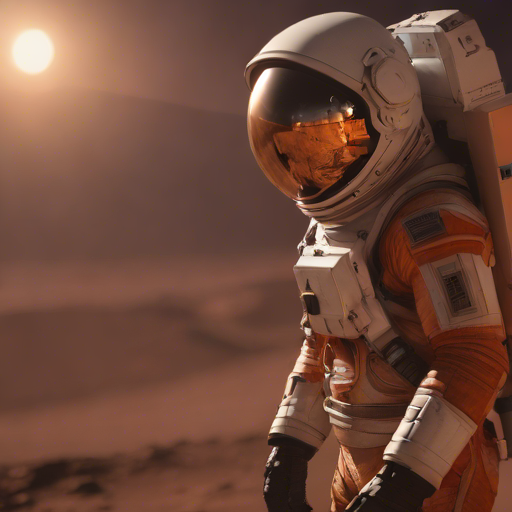

In [3]:
# Escribe aquí la descripción de la imagen (funciona mejor en inglés)
prompt = "A cinematic portrait of an astronaut on Mars, hyperrealistic, dramatic lighting, 8k resolution, detailed digital art"

# Generamos la imagen (SDXL-Turbo solo necesita entre 1 y 4 pasos)
imagen = pipe(
    prompt=prompt,
    num_inference_steps=2,
    guidance_scale=0.0
).images[0]

# Mostrar la imagen en pantalla
imagen

In [4]:
from google.colab import files

# Guardar en el disco temporal de Colab
imagen.save("resultado.png")

# Descargar a tu PC
files.download("resultado.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
!pip install -q gradio diffusers transformers accelerate torch

In [6]:
import gradio as gr
import torch
from diffusers import StableDiffusionXLPipeline

# 1. Cargar el modelo en la GPU
print("Cargando modelo...")
pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=torch.float16,
    variant="fp16"
).to("cuda")
print("¡Modelo listo!")

# 2. Función que ejecuta la generación
def generar_imagen(prompt, pasos, guia):
    imagen = pipe(
        prompt=prompt,
        num_inference_steps=pasos,
        guidance_scale=guia
    ).images[0]
    return imagen

# 3. Diseño de la interfaz web
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🎨 Generador de Imágenes con SDXL Turbo")
    gr.Markdown("Escribe tu descripción en inglés para obtener el mejor resultado.")

    with gr.Row():
        with gr.Column():
            prompt_input = gr.Textbox(
                label="Prompt (Descripción)",
                placeholder="Ej: A futuristic cyberpunk city at night, neon lights, 8k resolution, cinematic...",
                lines=3
            )
            pasos_slider = gr.Slider(
                minimum=1, maximum=4, value=2, step=1,
                label="Pasos de inferencia (Para este modelo, 2 a 4 es ideal)"
            )
            guia_slider = gr.Slider(
                minimum=0.0, maximum=2.0, value=0.0, step=0.1,
                label="Guidance Scale (Recomendado 0.0 para Turbo)"
            )
            btn_generar = gr.Button("Generar Imagen", variant="primary")

        with gr.Column():
            output_image = gr.Image(label="Resultado", type="pil")

    # Conectar el botón con la función
    btn_generar.click(
        fn=generar_imagen,
        inputs=[prompt_input, pasos_slider, guia_slider],
        outputs=output_image
    )

# 4. Iniciar la app (share=True genera un enlace público temporal)
demo.launch(share=True)

Cargando modelo...


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

¡Modelo listo!


/tmp/ipykernel_1322/3197029574.py:24: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b3de607b57da4eb28e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [8]:
import os
from google.colab import drive

# Conectar Drive
drive.mount('/content/drive')

# Crear carpeta dedicada para tus imágenes generadas
output_dir = "/content/drive/MyDrive/SDXL_Generaciones"
os.makedirs(output_dir, exist_ok=True)
print(f"Carpeta lista en Drive: {output_dir}")

Mounted at /content/drive
Carpeta lista en Drive: /content/drive/MyDrive/SDXL_Generaciones


In [9]:
import os
import time
import random
import gradio as gr
import torch
from diffusers import StableDiffusionXLPipeline

# Ruta de guardado en Drive
output_dir = "/content/drive/MyDrive/SDXL_Generaciones"

def generar_y_guardar(prompt, pasos, guia, seed, usar_seed_aleatoria):
    # 1. Gestionar la semilla
    if usar_seed_aleatoria:
        actual_seed = random.randint(0, 2**32 - 1)
    else:
        actual_seed = int(seed)

    generator = torch.Generator("cuda").manual_seed(actual_seed)

    # 2. Generar imagen
    imagen = pipe(
        prompt=prompt,
        num_inference_steps=pasos,
        guidance_scale=guia,
        generator=generator
    ).images[0]

    # 3. Guardar en Google Drive con timestamp
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    filename = f"{timestamp}_seed_{actual_seed}.png"
    filepath = os.path.join(output_dir, filename)
    imagen.save(filepath)

    estado = f"Guardada en Drive: {filename} | Semilla usada: {actual_seed}"
    return imagen, estado

# Interfaz gráfica mejorada
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🎨 Generador de Imágenes con Autoguardado")
    gr.Markdown("Las imágenes se guardan automáticamente en tu Google Drive (`SDXL_Generaciones`).")

    with gr.Row():
        with gr.Column():
            prompt_input = gr.Textbox(
                label="Prompt (Descripción en inglés)",
                placeholder="A cyberpunk street with neon signs, rain reflections, highly detailed, 8k...",
                lines=3
            )

            with gr.Row():
                pasos_slider = gr.Slider(minimum=1, maximum=4, value=2, step=1, label="Pasos")
                guia_slider = gr.Slider(minimum=0.0, maximum=2.0, value=0.0, step=0.1, label="Guidance")

            with gr.Row():
                seed_input = gr.Number(value=42, label="Semilla fija", precision=0)
                random_seed_cb = gr.Checkbox(label="Semilla aleatoria", value=True)

            btn_generar = gr.Button("Generar y Guardar", variant="primary")

        with gr.Column():
            output_image = gr.Image(label="Resultado", type="pil")
            status_text = gr.Markdown(label="Información")

    btn_generar.click(
        fn=generar_y_guardar,
        inputs=[prompt_input, pasos_slider, guia_slider, seed_input, random_seed_cb],
        outputs=[output_image, status_text]
    )

demo.launch(share=True)

/tmp/ipykernel_1322/2082358802.py:38: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2da175ef2446b85ff8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
